In [55]:
import sys
sys.path.append("..")
import torch
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [4, 4]
torch.manual_seed(0)
import seaborn as sns
# Set plotting style
sns.set(style="white", context="talk")
plt.rcParams['savefig.facecolor'] = 'white'


from engression import engression
from engression.data.simulator import preanm_simulator

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Simulate data


In [57]:
# x, y = preanm_simulator("square", n=10000, x_lower=0, x_upper=2, noise_std=1, train=True, device=device)
# x_eval, y_eval_med, y_eval_mean = preanm_simulator("square", n=1000, x_lower=0, x_upper=4, noise_std=1, train=False, device=device)

# print("Shapes of everything:", x.shape, y.shape, x_eval.shape, y_eval_med.shape, y_eval_mean.shape)

In [58]:
import numpy as np
def gen_data(seed, n_samples, n_segments=3, x_range=[-3.0, 3.0], noise_std=0.1):
    """
    Generates a classical 1D-1D regression dataset: y = sin(3x) + 0.5x
    Segments are assigned based on spatial position (x-value), allowing
    for easy OOD splitting (e.g., train on segments [0,1], test on [2]).
    """
    np.random.seed(seed)
    
    # 1. Generate X uniformly across the full range
    x_min, x_max = x_range
    X = np.random.uniform(x_min, x_max, n_samples)
    
    # 2. Define the unchanging relation P(Y|X) (Concept)
    # y = sin(3x) + 0.5x is classic because it has both trend and periodicity
    Y = np.sin(10 * X) + 0.5 * X
    
    # Add noise
    noise = np.random.normal(0, noise_std, n_samples)
    Y += noise
    
    # 3. Create Segments spatially
    # We divide the x_range into n_segments equal distinct regions
    bins = np.linspace(x_min, x_max, n_segments + 1)
    
    # np.digitize returns indices 1..N, we want 0..N-1
    segs = np.digitize(X, bins) - 1
    
    # Clip to ensure bounds (in case of float precision issues at max edge)
    segs = np.clip(segs, 0, n_segments - 1)
    
    # 4. Format Output
    # data shape: (N, 2) -> [x, y]
    # segs shape: (N,)
    data = np.column_stack((X, Y))
    
    return data, segs

data, segs = gen_data(seed=42, n_samples=2000, n_segments=5, x_range=[-4.0, 4.0], noise_std=0.1)

##Create x,y, x_eval, y_eval_med, y_eval_mean tensors, usingt he segment IDS
train_seg_ids = [1, 2, 3] # Train on the middle
train_mask = np.isin(segs, train_seg_ids)
x = torch.Tensor(data[train_mask, 0]).unsqueeze(1).to(device)
y = torch.Tensor(data[train_mask, 1]).unsqueeze(1).to(device)

eval_mask = ~train_mask
x_eval = torch.Tensor(data[eval_mask, 0]).unsqueeze(1).to(device)
y_eval_med = torch.Tensor(data[eval_mask, 1]).unsqueeze(1).to(device)
y_eval_mean = y_eval_med  # In this synthetic case, median=mean

print("Shapes of everything:", x.shape, y.shape, x_eval.shape, y_eval_med.shape, y_eval_mean.shape)

Shapes of everything: torch.Size([1169, 1]) torch.Size([1169, 1]) torch.Size([831, 1]) torch.Size([831, 1]) torch.Size([831, 1])


## Engression

In [59]:
# Fit an engression model
engressor = engression(x, y, lr=0.005, num_epochs=5000, batch_size=1000, device=device)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Batch is larger than half of the sample size. Training based on full-batch gradient descent.
[Epoch 1 (0%)] energy-loss: 0.6771,  E(|Y-Yhat|): 0.8789,  E(|Yhat-Yhat'|): 0.4035
[Epoch 100 (2%)] energy-loss: 0.4333,  E(|Y-Yhat|): 0.9223,  E(|Yhat-Yhat'|): 0.9781
[Epoch 200 (4%)] energy-loss: 0.4270,  E(|Y-Yhat|): 0.9098,  E(|Yhat-Yhat'|): 0.9657
[Epoch 300 (6%)] energy-loss: 0.4267,  E(|Y-Yhat|): 0.9220,  E(|Yhat-Yhat'|): 0.9908
[Epoch 400 (8%)] energy-loss: 0.4474,  E(|Y-Yhat|): 0.8891,  E(|Yhat-Yhat'|): 0.8835
[Epoch 500 (10%)] energy-loss: 0.4164,  E(|Y-Yhat|): 0.8883,  E(|Yhat-Yhat'|): 0.9439
[Epoch 600 (12%)] energy-loss: 0.4091,  E(|Y-Yhat|): 0.9115,  E(|Yhat-Yhat'|): 1.0048
[Epoch 700 (14%)] energy-loss: 0.4091,  E(|Y-Yhat|): 0.8732,  E(|Yhat-Yhat'|): 0.9283
[Ep

In [60]:
# Summarize model information
engressor.summary()

Engression model with
	 number of layers: 2
	 hidden dimensions: 100
	 noise dimensions: 100
	 residual blocks: False
	 number of epochs: 5000
	 batch size: 1169
	 learning rate: 0.005
	 standardization: True
	 training mode: False
	 device: cpu

Training loss (original scale):
	 energy-loss: 0.42, 
	E(|Y-Yhat|): 0.86, 
	E(|Yhat-Yhat'|): 0.87


In [61]:
# Evaluation
print("L2 loss:", engressor.eval_loss(x_eval, y_eval_mean, loss_type="l2"))
print("correlation between predicted and true means:", engressor.eval_loss(x_eval, y_eval_mean, loss_type="cor"))

L2 loss: 0.6716669201850891
correlation between predicted and true means: 0.9149621725082397


In [62]:
# Predictions
y_pred = engressor.predict(x_eval, target="mean", sample_size=1000)

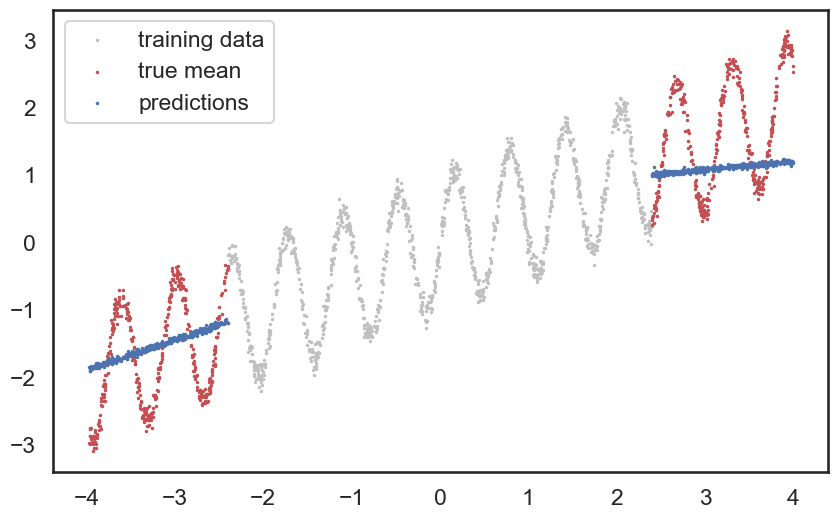

In [63]:
## increase figure size
plt.rcParams["figure.figsize"] = [10, 6]
plt.scatter(x.cpu(), y.cpu(), label="training data", s=1, color="silver")
# plt.plot(x_eval.cpu(), y_eval_mean.cpu(), label="true mean", color="C3")
plt.scatter(x_eval.cpu(), y_eval_mean.cpu(), label="true mean", color="C3", s=1)
plt.scatter(x_eval.cpu(), y_pred.cpu(), label="predictions", s=1)
# plt.ylim(-0.1, 9)
plt.legend(); plt.show()

## Baseline: $L_2$ regression

In [64]:
from engression.models import Net

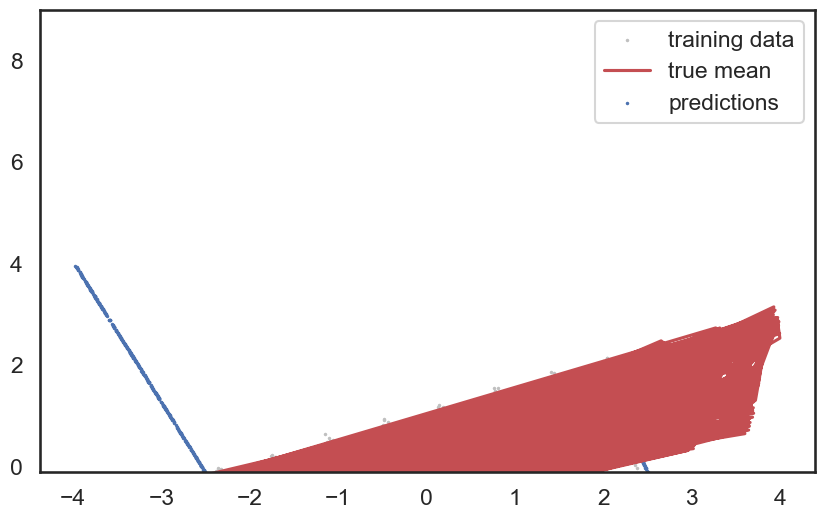

In [65]:
# Build a model with the same architecture
model = Net(num_layer=2, hidden_dim=100) # NN with the same architecture
opt = torch.optim.Adam(model.parameters(), lr=0.005) # same optimizer

# L2 regression training
model.train()
for i in range(500):
    model.zero_grad()
    y_pred = model(x)
    loss = (y_pred - y).pow(2).mean()
    loss.backward()
    opt.step()

# Evaluation
model.eval()
y_pred = model(x_eval).detach()
plt.scatter(x.cpu(), y.cpu(), label="training data", s=1, color="silver")
plt.plot(x_eval.cpu(), y_eval_mean.cpu(), label="true mean", color="C3")
plt.scatter(x_eval.cpu(), y_pred.cpu(), label="predictions", s=1)
plt.ylim(-0.1, 9)
plt.legend(); plt.show()